In [1]:
from pathlib import Path
import ast
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "figure.titlesize": 18,
})

ALGO_COLORS = {
    "nads_binary_search": "#d62728",
    "approx": "#1f77b4",
    "goldberg_liu": "#2ca02c",
    "degree_threshold": "#9467bd",
    "degree_discount": "#ff7f0e",
    "degree_connected": "#8c564b",
    "degree": "#e377c2",
    "betweenness": "#17becf",
    "high_thetas": "#7f7f7f",
}

save = 0

## Functions
All reusable helpers are centralized in the next code cell.

In [2]:
def finalize_axes(ax, grid_axis="both", grid_style="--", grid_lw=0.7, grid_alpha=0.6):
    ax.grid(True, axis=grid_axis, linestyle=grid_style, linewidth=grid_lw, alpha=grid_alpha)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def maybe_save(fig, name):
    if save:
        fig.savefig(figures_dir / name, dpi=220, bbox_inches="tight")


def resolve_project_root() -> Path:
    root = Path.cwd()
    if not (root / "results").exists() and (root.parent / "results").exists():
        root = root.parent
    return root


def parse_maybe_json_or_literal(raw):
    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return None
    if isinstance(raw, str):
        raw = raw.strip()
        if not raw:
            return None
        try:
            return json.loads(raw)
        except json.JSONDecodeError:
            return ast.literal_eval(raw)
    return raw


def ensure_approx_start_event(raw_history, n_nodes):
    n_nodes = float(n_nodes)
    parsed = parse_maybe_json_or_literal(raw_history)
    if not isinstance(parsed, (list, tuple)) or len(parsed) == 0:
        return json.dumps([[n_nodes, 0.0]])

    clean = []
    for point in parsed:
        if not isinstance(point, (list, tuple)) or len(point) < 2:
            continue
        try:
            k = float(point[0])
            t = float(point[1])
        except (TypeError, ValueError):
            continue
        if np.isfinite(k) and np.isfinite(t):
            clean.append([k, t])

    if not clean:
        return json.dumps([[n_nodes, 0.0]])

    clean.sort(key=lambda p: p[1])
    has_start = any(np.isclose(t, 0.0, atol=1e-12) and np.isclose(k, n_nodes, atol=1e-9) for k, t in clean)
    if not has_start:
        clean = [[n_nodes, 0.0]] + clean
    return json.dumps(clean)


def load_results(results_dir: Path) -> pd.DataFrame:
    files = sorted(results_dir.glob("technology_diffusion_results__*.csv"))
    if not files:
        fallback = results_dir / "technology_diffusion_results.csv"
        if fallback.exists():
            files = [fallback]
    if not files:
        raise FileNotFoundError(f"No result CSV files found in {results_dir}")

    frames = []
    for file in files:
        frame = pd.read_csv(file).copy()
        frame["source_file"] = file.name
        if "history" not in frame.columns:
            frame["history"] = None
        if "selected_seed_nodes" not in frame.columns:
            frame["selected_seed_nodes"] = None
        frame["selected_seed_nodes"] = frame["selected_seed_nodes"].apply(parse_maybe_json_or_literal)
        frames.append(frame)

    df = pd.concat(frames, ignore_index=True)

    for col in ["n_nodes", "c", "seed", "total_time", "K"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "K" in df.columns and "n_nodes" in df.columns:
        missing_k = df["K"].isna() & df["n_nodes"].notna()
        df.loc[missing_k, "K"] = df.loc[missing_k, "n_nodes"].astype(float)
        if "history" in df.columns:
            df.loc[missing_k, "history"] = df.loc[missing_k, "n_nodes"].apply(lambda n: json.dumps([[float(n), 0.0]]))

    if {"algorithm", "history", "n_nodes"}.issubset(df.columns):
        approx_mask = df["algorithm"].eq("approx") & df["n_nodes"].notna()
        df.loc[approx_mask, "history"] = df.loc[approx_mask].apply(
            lambda row: ensure_approx_start_event(row.get("history"), row.get("n_nodes")),
            axis=1,
        )

    return df


def parse_history(raw):
    parsed = parse_maybe_json_or_literal(raw)
    if not isinstance(parsed, (list, tuple)) or len(parsed) == 0:
        return None

    arr = np.asarray(parsed, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 2:
        return None

    values, times = arr[:, 0], arr[:, 1]
    mask = np.isfinite(values) & np.isfinite(times)
    if not np.any(mask):
        return None

    values, times = values[mask], times[mask]
    order = np.argsort(times)
    return times[order], values[order]


def mean_step_curve(histories, t_end=None):
    parsed = [p for p in (parse_history(h) for h in histories) if p is not None]
    if not parsed:
        return None

    all_event_times = np.concatenate([p[0] for p in parsed])
    all_event_times = all_event_times[np.isfinite(all_event_times)]
    if all_event_times.size == 0:
        return None

    t_grid = np.unique(np.concatenate(([0.0], all_event_times)))
    if t_end is not None and float(t_end) > 0:
        t_grid = np.unique(np.concatenate((t_grid, [float(t_end)])))

    sampled = []
    for t_hist, k_hist in parsed:
        idx = np.searchsorted(t_hist, t_grid, side="right") - 1
        idx = np.clip(idx, 0, len(k_hist) - 1)
        sampled.append(k_hist[idx])

    return t_grid, np.vstack(sampled).mean(axis=0)

## Load and Normalize Results

In [3]:
project_root = resolve_project_root()
figures_dir = project_root / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
results_dir = project_root / "results" / "technology diffusion"
if not results_dir.exists():
    raise FileNotFoundError(f"Results directory not found: {results_dir}")

df_results = load_results(results_dir)
print(f"Loaded {len(df_results)} rows from {results_dir}")
df_results.head()

Loaded 4500 rows from /Users/matteobergamaschi/Desktop/td_git/results/technology diffusion


,algorithm,n_nodes,c,seed,total_time,K,history,source_file,selected_seed_nodes
0,approx,200,1,1,2.1976,18.0,"[[200.0, 0.0], [18.0, 2.1976]]",technology_diffusion_results__seed-1.csv,None
1,betweenness,200,1,1,0.2837,39.0,"[[200, 0.0], [100, 0.0741], [50, 0.129], [39, ...",technology_diffusion_results__seed-1.csv,None
2,degree,200,1,1,0.0631,52.0,"[[200, 0.0], [100, 0.0321], [52, 0.0475], [52,...",technology_diffusion_results__seed-1.csv,None
3,degree_connected,200,1,1,0.0214,52.0,"[[200, 0.0], [100, 0.0089], [52, 0.0151], [52,...",technology_diffusion_results__seed-1.csv,None
4,degree_discount,200,1,1,0.1136,55.0,"[[200, 0.0], [100, 0.0423], [56, 0.0653], [55,...",technology_diffusion_results__seed-1.csv,None


## Mean K by Number of Nodes

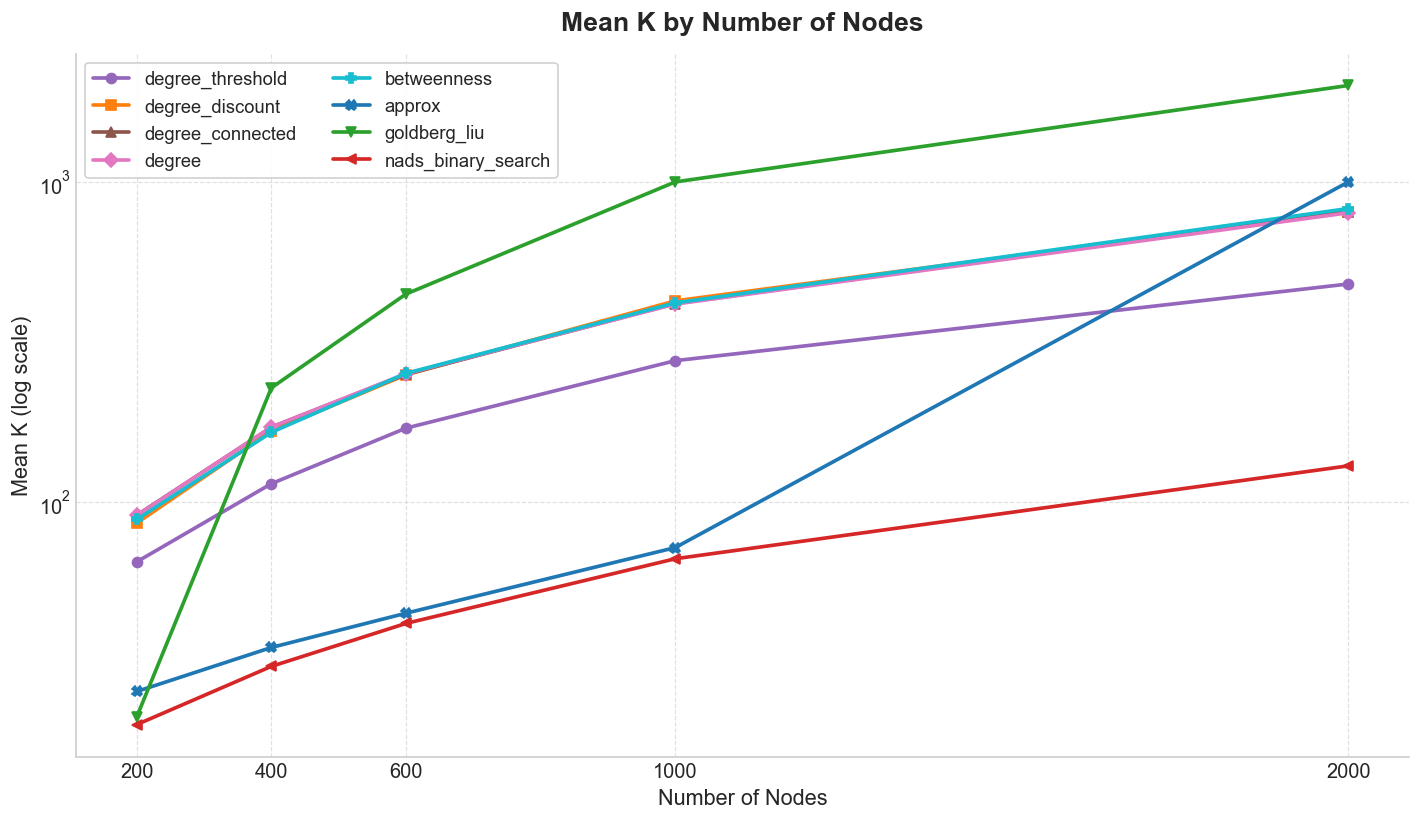

In [10]:
algorithm_order = [
    "degree_threshold",
    "degree_discount",
    "degree_connected",
    "degree",
    "betweenness",
    "approx",
    "goldberg_liu",
    "nads_binary_search",
]

plot_df = (
    df_results.groupby(["n_nodes", "algorithm"], as_index=False)
    .agg(mean_K=("K", "mean"), mean_total_time=("total_time", "mean"))
    .sort_values(["n_nodes", "algorithm"])
)

pivot_k = plot_df.pivot(index="n_nodes", columns="algorithm", values="mean_K").sort_index()
available_algorithms = [a for a in algorithm_order if a in pivot_k.columns]
if not available_algorithms:
    raise ValueError("No expected algorithms found in df_results")

fig, ax = plt.subplots(figsize=(12, 7), dpi=120)
markers = ["o", "s", "^", "D", "P", "X", "v", "<"]
fallback_gl = pd.Series(pivot_k.index, index=pivot_k.index, dtype=float)

for i, alg in enumerate(available_algorithms):
    series = pivot_k[alg]
    if alg == "goldberg_liu":
        series = series.fillna(fallback_gl)
    ax.plot(
        pivot_k.index,
        series,
        marker=markers[i % len(markers)],
        linewidth=2.2,
        color=ALGO_COLORS.get(alg, "#4c4c4c"),
        label=alg,
    )

ax.set_title("Mean K by Number of Nodes", pad=14, weight="bold")
ax.set_xlabel("Number of Nodes")
ax.set_ylabel("Mean K (log scale)")
ax.set_yscale("log")
ax.set_xticks(pivot_k.index.to_list())
finalize_axes(ax)
ax.legend(frameon=True, framealpha=0.9, ncols=2, loc="best")

fig.tight_layout()
maybe_save(fig, "mean_k_by_nodes.png")
plt.show()

## Mean History Step-Curves

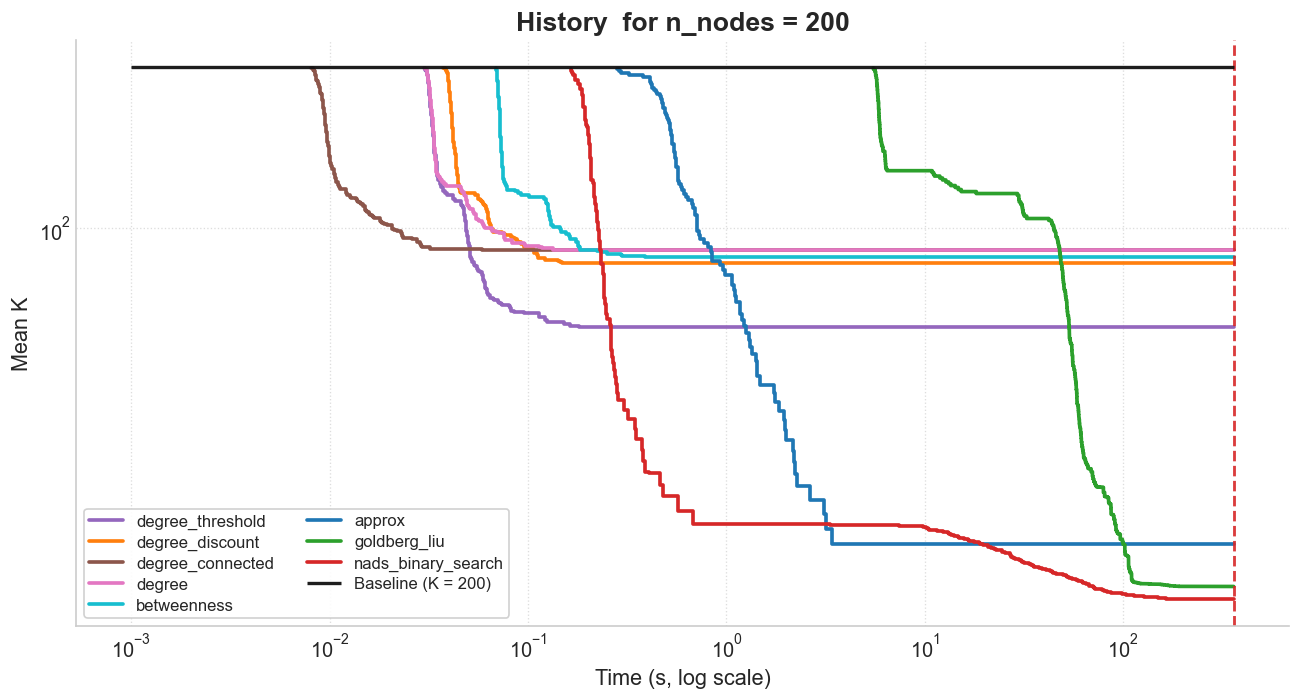

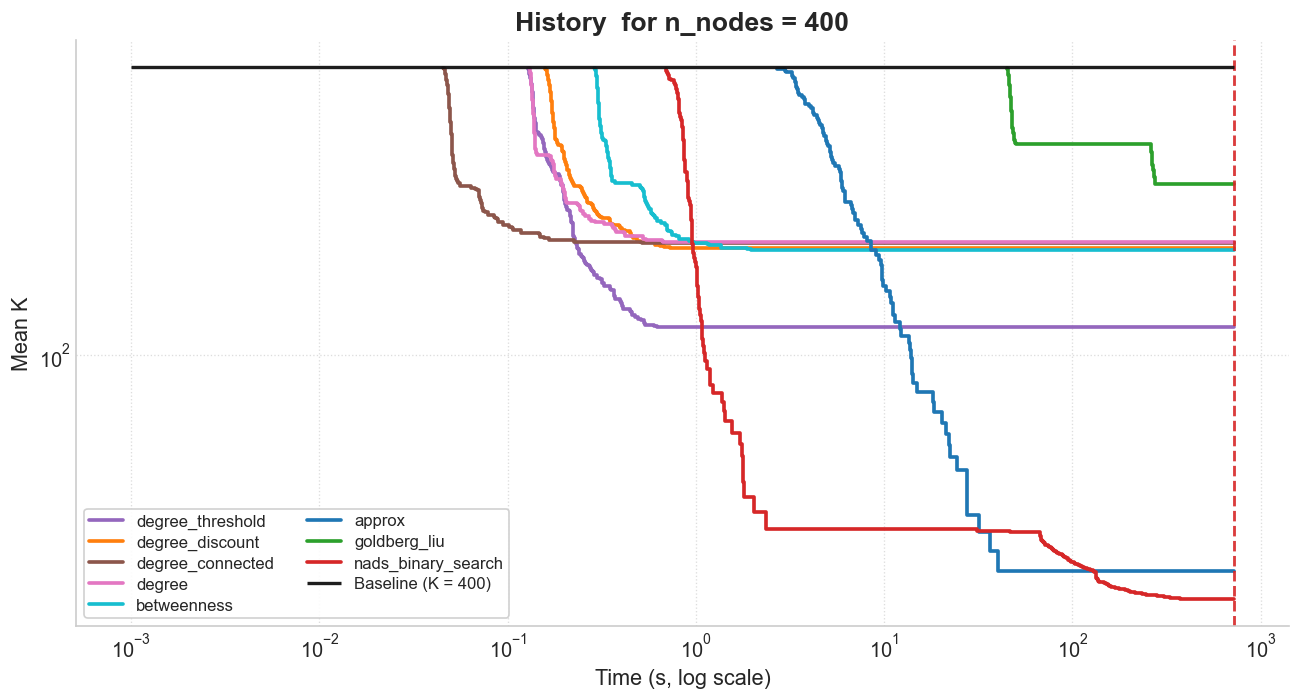

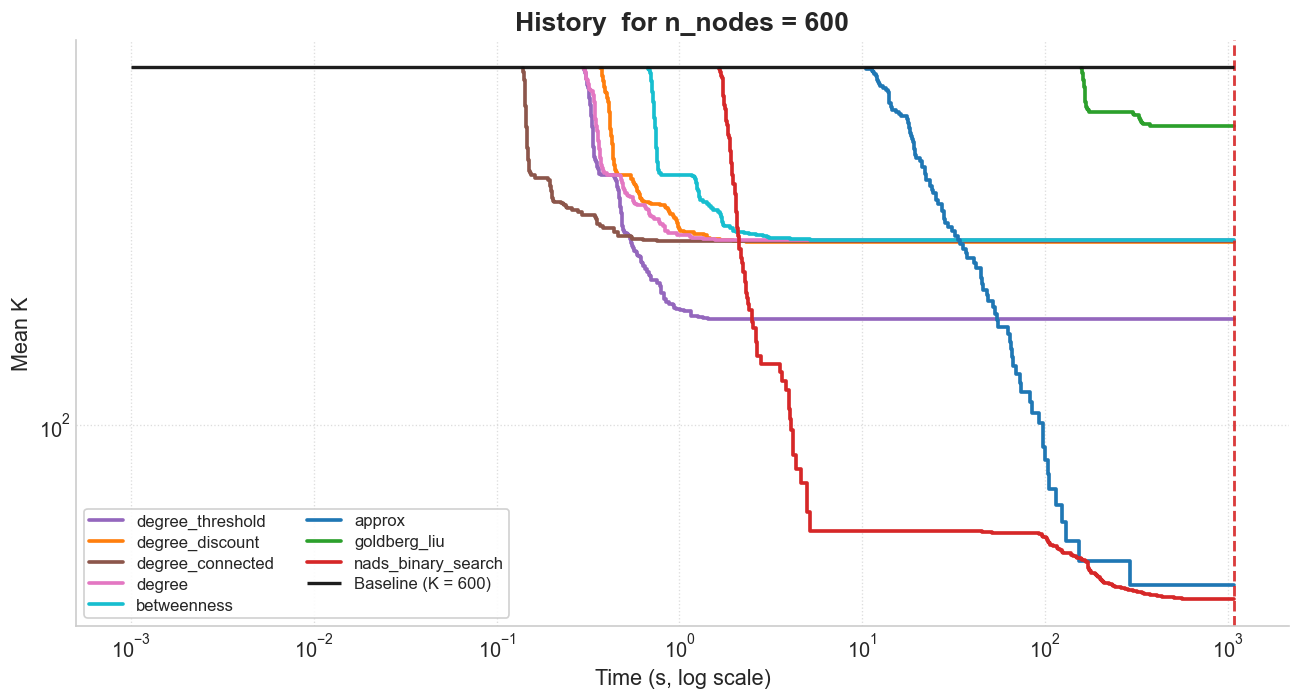

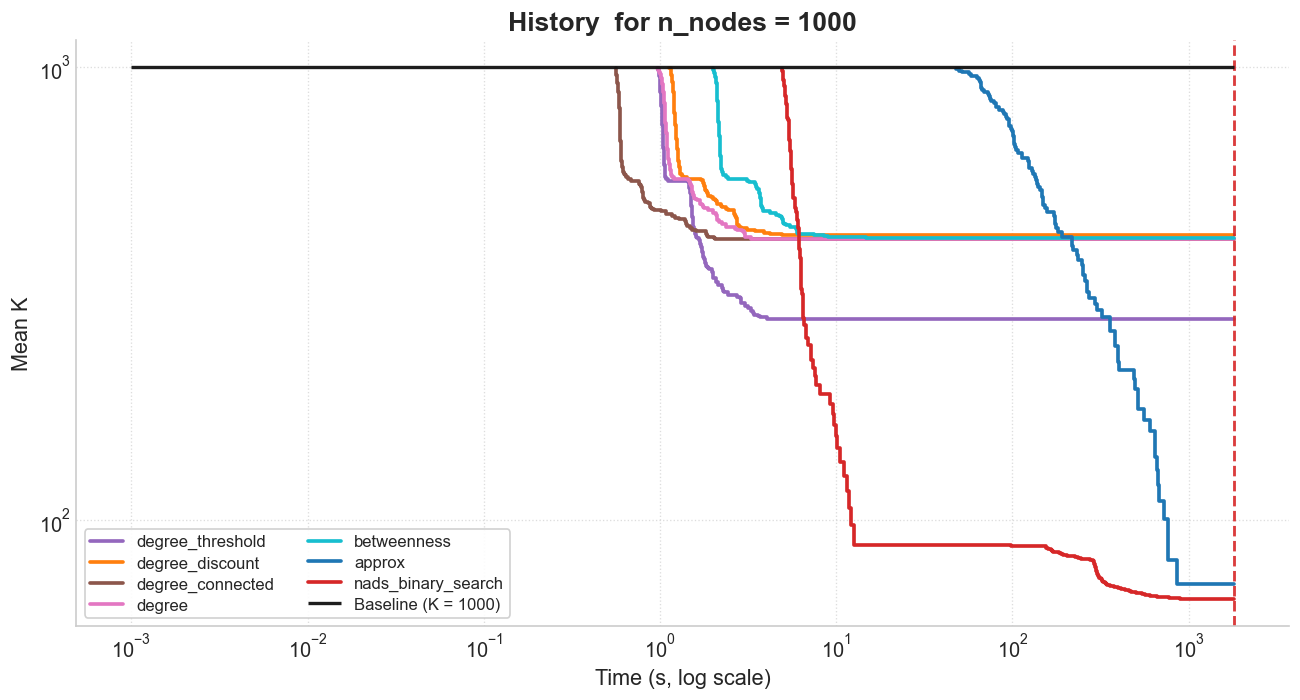

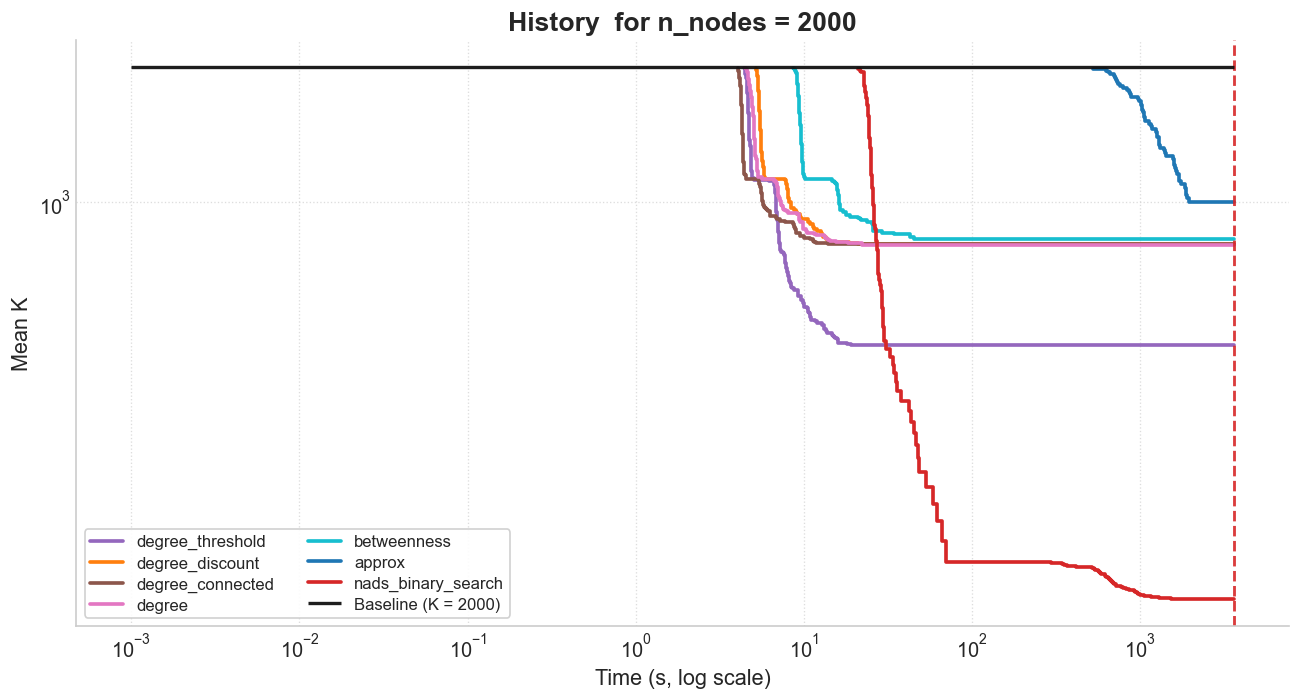

In [31]:
n_values = sorted(df_results["n_nodes"].dropna().unique())
if not n_values:
    raise ValueError("No n_nodes values found in df_results")

history_algorithms = [a for a in available_algorithms if a != "high_thetas"]

for n in n_values:
    df_n = df_results[df_results["n_nodes"] == n].copy()
    budget_s = (n / 100) * 180
    worst_k = float(n)
    tol = max(1e-9, 1e-6 * worst_k)

    fig, ax = plt.subplots(figsize=(11, 6), dpi=120)
    plotted = 0
    y_min_curve = np.inf
    for alg in history_algorithms:
        histories = df_n.loc[df_n["algorithm"] == alg, "history"].tolist()
        curve = mean_step_curve(histories, t_end=budget_s)
        if curve is None:
            continue

        t_alg, y_mean = curve

        # Keep only the portion strictly below the worst-case level y = n_nodes.
        keep_mask = y_mean < (worst_k - tol)
        if not np.any(keep_mask):
            continue

        keep_idx = np.where(keep_mask)[0]
        first_keep, last_keep = keep_idx[0], keep_idx[-1]
        t_plot = t_alg[first_keep : last_keep + 1]
        y_plot = y_mean[first_keep : last_keep + 1]
        y_plot = np.minimum(y_plot, worst_k - tol)

        positive = y_plot[y_plot > 0]
        if positive.size:
            y_min_curve = min(y_min_curve, float(np.min(positive)))

        ax.step(
            np.maximum(t_plot, 1e-3),
            y_plot,
            where="post",
            linewidth=2.2,
            color=ALGO_COLORS.get(alg, "#4c4c4c"),
            label=alg,
        )
        plotted += 1

    if plotted == 0:
        plt.close(fig)
        continue

    x_left = 1e-3
    x_right = max(x_left, budget_s * (1 - 1e-9))
    ax.hlines(
        worst_k,
        xmin=x_left,
        xmax=x_right,
        color="#111111",
        linestyle="-",
        linewidth=2.0,
        alpha=0.95,
        zorder=5,
        label=f"Baseline (K = {worst_k:.0f}) ",
    )

    ax.axvline(budget_s, color="#d62728", linestyle="--", linewidth=1.7, alpha=0.9)
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_title(f"History  for n_nodes = {int(n)}", weight="bold")
    ax.set_xlabel("Time (s, log scale)")
    ax.set_ylabel("Mean K")
    finalize_axes(ax, grid_axis="both", grid_style=":", grid_lw=0.8, grid_alpha=0.65)
    ax.legend(
        loc="lower left",
        frameon=True,
        framealpha=0.9,
        ncols=2,
        fontsize=10,
        labelspacing=0.35,
        borderpad=0.3,
    )

    fig.tight_layout()
    maybe_save(fig, f"mean_history_n_{int(n)}.png")
    plt.show()

## Rank Distribution by Algorithm

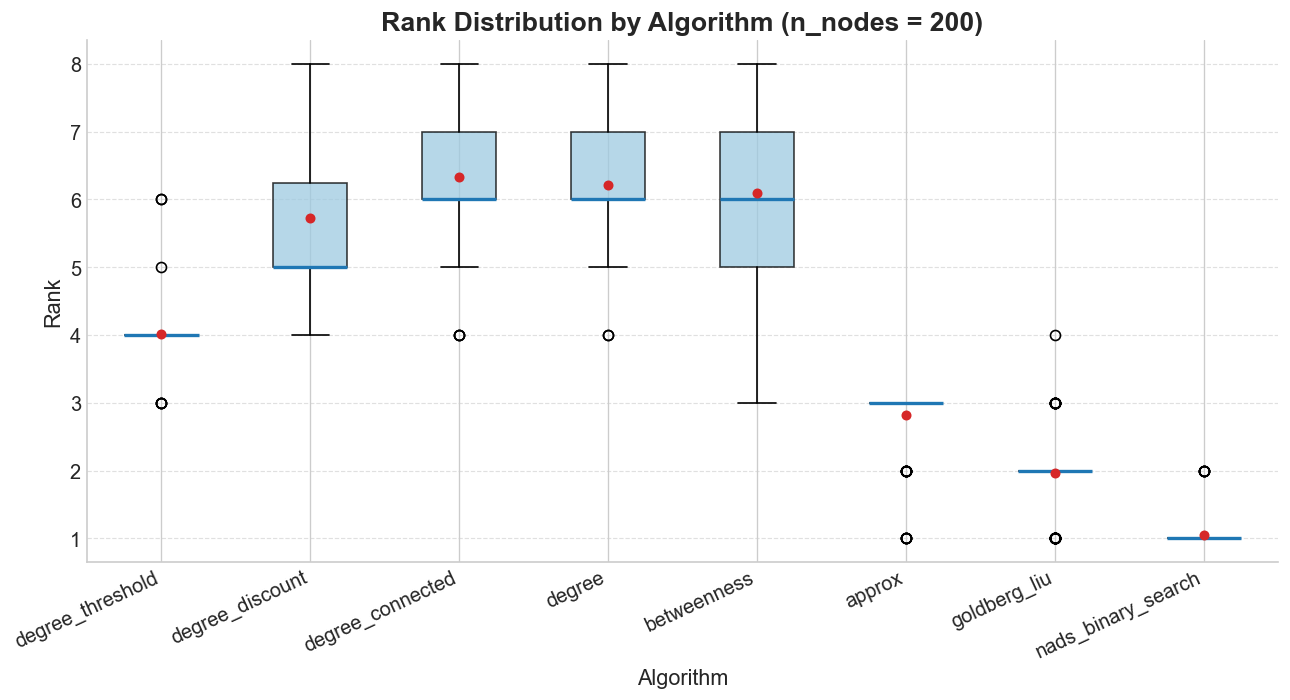

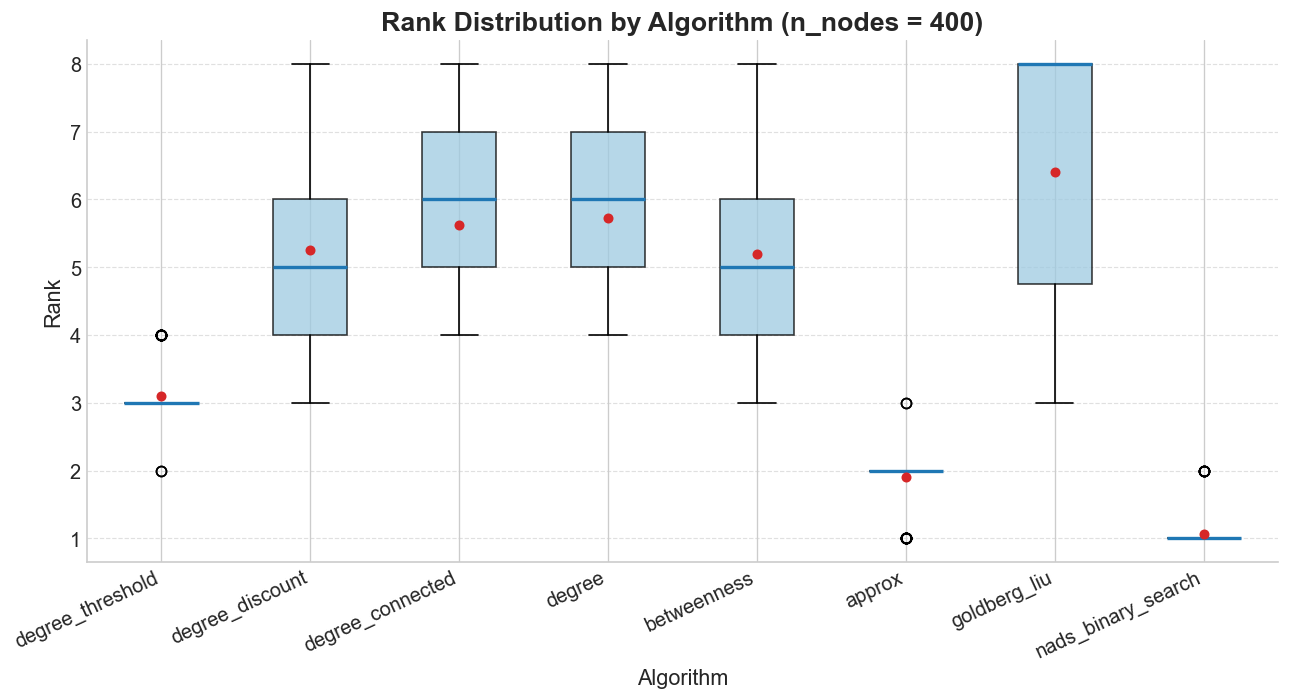

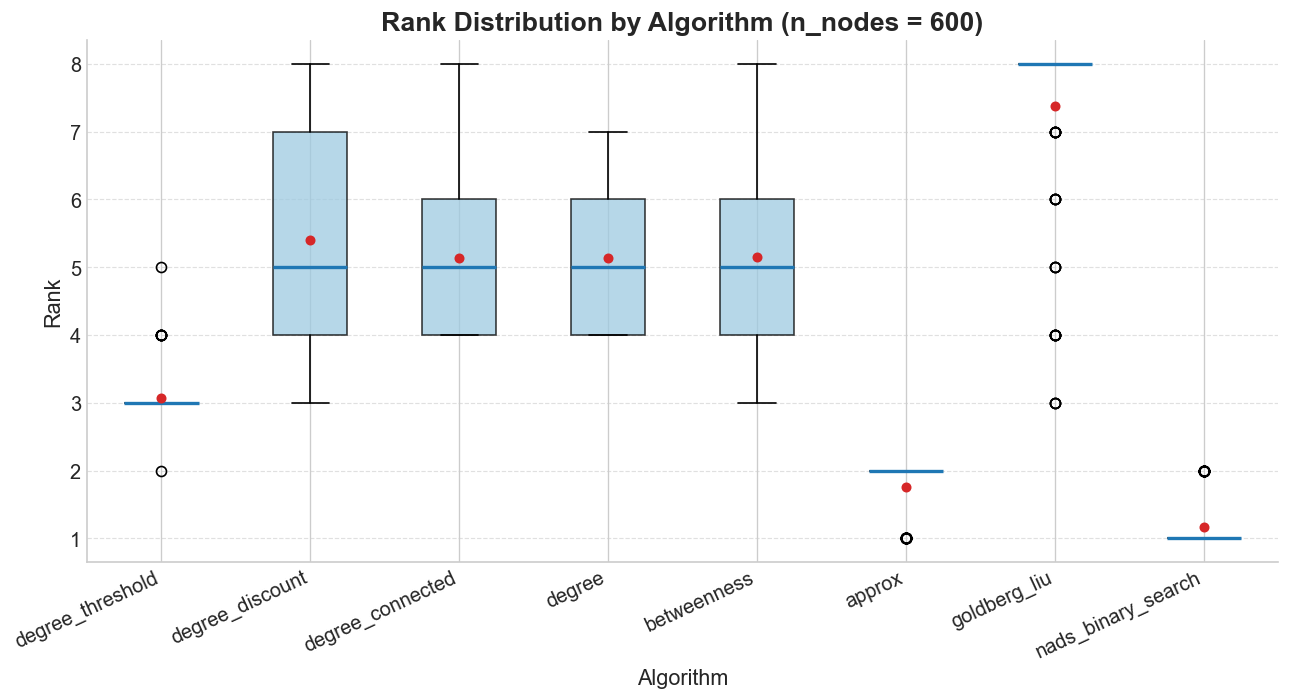

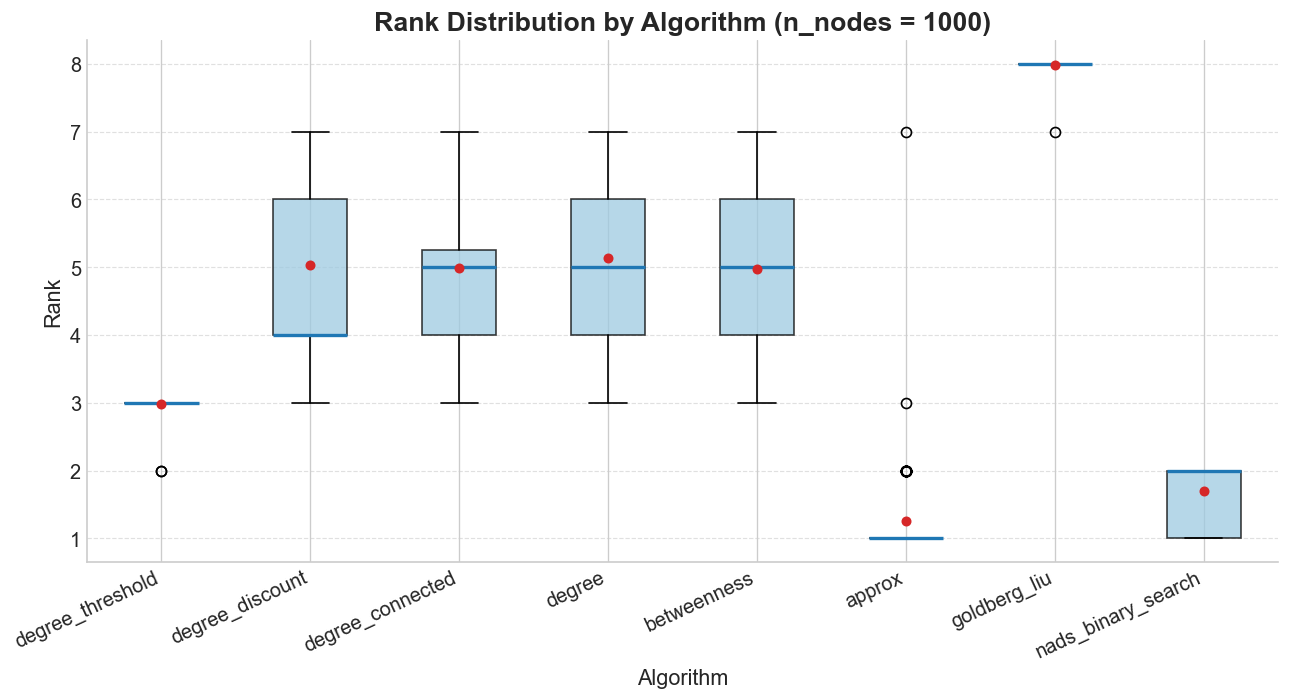

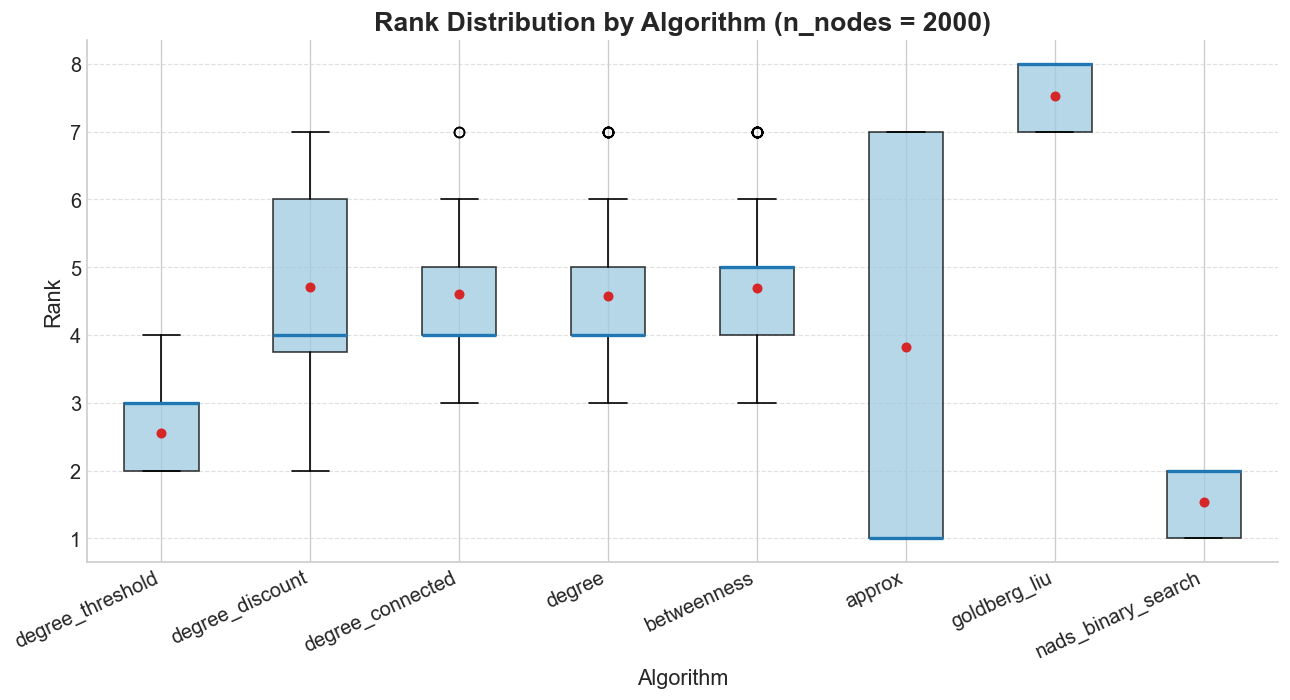

In [6]:
candidate_dims = ["n_nodes", "c", "seed"]
instance_keys = [col for col in candidate_dims if col in df_results.columns]

if "algorithm" not in df_results.columns or "K" not in df_results.columns:
    raise ValueError("df_results must contain at least 'algorithm' and 'K' columns")
if "n_nodes" not in df_results.columns:
    raise ValueError("df_results must contain 'n_nodes' for this plot")
if not instance_keys:
    raise ValueError("At least one of ['n_nodes', 'c', 'seed'] must be present in df_results")

rank_source = df_results.dropna(subset=instance_keys + ["algorithm"]).copy()
rank_source = rank_source[rank_source["algorithm"] != "high_thetas"].copy()

rank_algorithms = [a for a in algorithm_order if a in rank_source["algorithm"].unique()]
if not rank_algorithms:
    rank_algorithms = sorted(rank_source["algorithm"].dropna().unique())

instances = rank_source[instance_keys].drop_duplicates().copy()
instances["_k"] = 1
algorithms_df = pd.DataFrame({"algorithm": rank_algorithms, "_k": 1})
rank_complete = instances.merge(algorithms_df, on="_k", how="inner").drop(columns=["_k"])

k_values = rank_source[instance_keys + ["algorithm", "K"]].copy()
rank_complete = rank_complete.merge(k_values, on=instance_keys + ["algorithm"], how="left")
rank_complete["K_for_rank"] = rank_complete["K"].fillna(np.inf)
rank_complete["rank_in_instance"] = (
    rank_complete.groupby(instance_keys)["K_for_rank"]
    .rank(method="min", ascending=True)
    .astype(int)
)

for n in sorted(rank_complete["n_nodes"].dropna().unique()):
    df_n = rank_complete[rank_complete["n_nodes"] == n].copy()
    if df_n.empty:
        continue

    box_data = [
        df_n.loc[df_n["algorithm"] == alg, "rank_in_instance"].dropna().to_numpy()
        for alg in rank_algorithms
    ]
    if all(len(arr) == 0 for arr in box_data):
        continue

    fig, ax = plt.subplots(figsize=(11, 6), dpi=120)
    bp = ax.boxplot(
        box_data,
        tick_labels=rank_algorithms,
        patch_artist=True,
        showmeans=True,
        meanprops={
            "marker": "o",
            "markerfacecolor": "#d62728",
            "markeredgecolor": "#d62728",
            "markersize": 5,
        },
    )

    for patch in bp["boxes"]:
        patch.set_facecolor("#9ecae1")
        patch.set_alpha(0.75)
    for median in bp["medians"]:
        median.set_color("#1f77b4")
        median.set_linewidth(2.0)

    ax.set_title(f"Rank Distribution by Algorithm (n_nodes = {int(n)})", weight="bold")
    ax.set_xlabel("Algorithm")
    ax.set_ylabel("Rank")
    finalize_axes(ax, grid_axis="y")
    plt.xticks(rotation=25, ha="right")

    fig.tight_layout()
    maybe_save(fig, f"rank_boxplot_n_{int(n)}.png")
    plt.show()

## Statistics

In [8]:
# --- Global dataset statistics ---
print("=== Dataset statistics ===")
print(f"Rows: {len(df_results):,}")

if "algorithm" in df_results.columns:
    alg_values = sorted(df_results["algorithm"].dropna().unique())
    print(f"Algorithms: {len(alg_values)}")
    print("Algorithm names: " + ", ".join(str(a) for a in alg_values))

if "n_nodes" in df_results.columns:
    node_values = sorted(df_results["n_nodes"].dropna().unique())
    print(f"n_nodes values: {len(node_values)}")
    if node_values:
        node_text = ", ".join(str(int(v)) if float(v).is_integer() else f"{float(v):g}" for v in node_values)
        print("n_nodes set: " + node_text)
        print(f"n_nodes range: min={float(np.min(node_values)):g}, max={float(np.max(node_values)):g}")

if "seed" in df_results.columns:
    print(f"Unique seeds: {df_results['seed'].nunique()}")
if "c" in df_results.columns:
    print(f"Unique c values: {df_results['c'].nunique()}")

# --- Approx failure statistics: failure <=> K == n_nodes ---
if {"algorithm", "K", "n_nodes"}.issubset(df_results.columns):
    approx_df = df_results[df_results["algorithm"] == "approx"].copy()
    approx_df["K_num"] = pd.to_numeric(approx_df["K"], errors="coerce")
    approx_df["n_num"] = pd.to_numeric(approx_df["n_nodes"], errors="coerce")
    approx_df = approx_df.dropna(subset=["K_num", "n_num"]).copy()

    print("\n=== Approx failure statistics (K == n_nodes) ===")
    total_approx = len(approx_df)

    if total_approx:
        is_failure = np.isclose(approx_df["K_num"], approx_df["n_num"], rtol=0.0, atol=1e-12)
        failures = int(is_failure.sum())
        success = total_approx - failures
        fail_rate = failures / total_approx

        print(f"Total approx runs (with valid K and n_nodes): {total_approx:,}")
        print(f"Failures (K == n_nodes): {failures:,}")
        print(f"Successes: {success:,}")
        print(f"Failure rate: {fail_rate:.2%}")

        by_n = (
            approx_df.assign(is_failure=is_failure)
            .groupby("n_num", as_index=False)
            .agg(
                total_runs=("is_failure", "size"),
                failures=("is_failure", "sum"),
            )
        )
        by_n["failure_rate"] = by_n["failures"] / by_n["total_runs"]
        by_n = by_n.sort_values("n_num")
        by_n["n_nodes"] = by_n["n_num"].map(lambda x: int(x) if float(x).is_integer() else float(x))
        by_n = by_n[["n_nodes", "total_runs", "failures", "failure_rate"]]

        print("\nFailure breakdown by n_nodes:")
        print(
            by_n.to_string(
                index=False,
                formatters={
                    "failure_rate": "{:.2%}".format,
                },
            )
        )
    else:
        print("No valid approx rows with both K and n_nodes.")
else:
    print("\nMissing one of required columns: algorithm, K, n_nodes")

=== Dataset statistics ===
Rows: 4,500
Algorithms: 9
Algorithm names: approx, betweenness, degree, degree_connected, degree_discount, degree_threshold, goldberg_liu, high_thetas, nads_binary_search
n_nodes values: 5
n_nodes set: 200, 400, 600, 1000, 2000
n_nodes range: min=200, max=2000
Unique seeds: 25
Unique c values: 4

=== Approx failure statistics (K == n_nodes) ===
Total approx runs (with valid K and n_nodes): 500
Failures (K == n_nodes): 48
Successes: 452
Failure rate: 9.60%

Failure breakdown by n_nodes:
 n_nodes  total_runs  failures failure_rate
     200         100         0        0.00%
     400         100         0        0.00%
     600         100         0        0.00%
    1000         100         1        1.00%
    2000         100        47       47.00%
